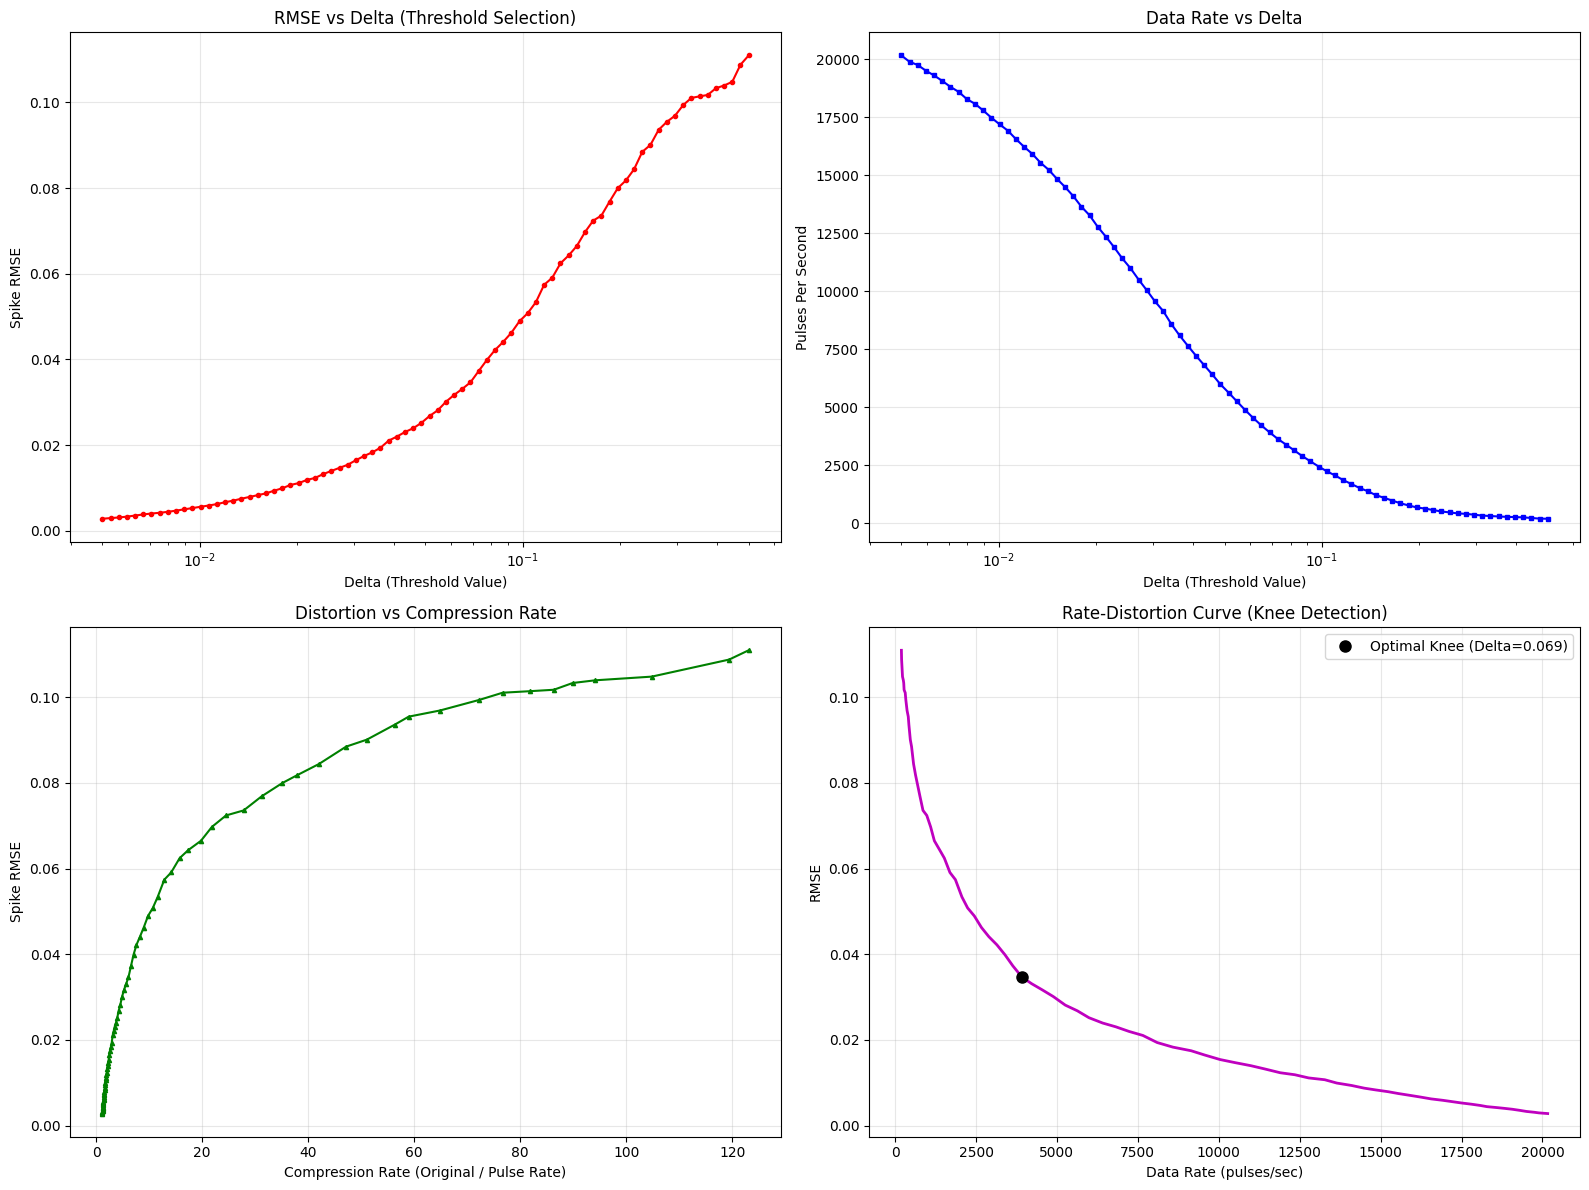

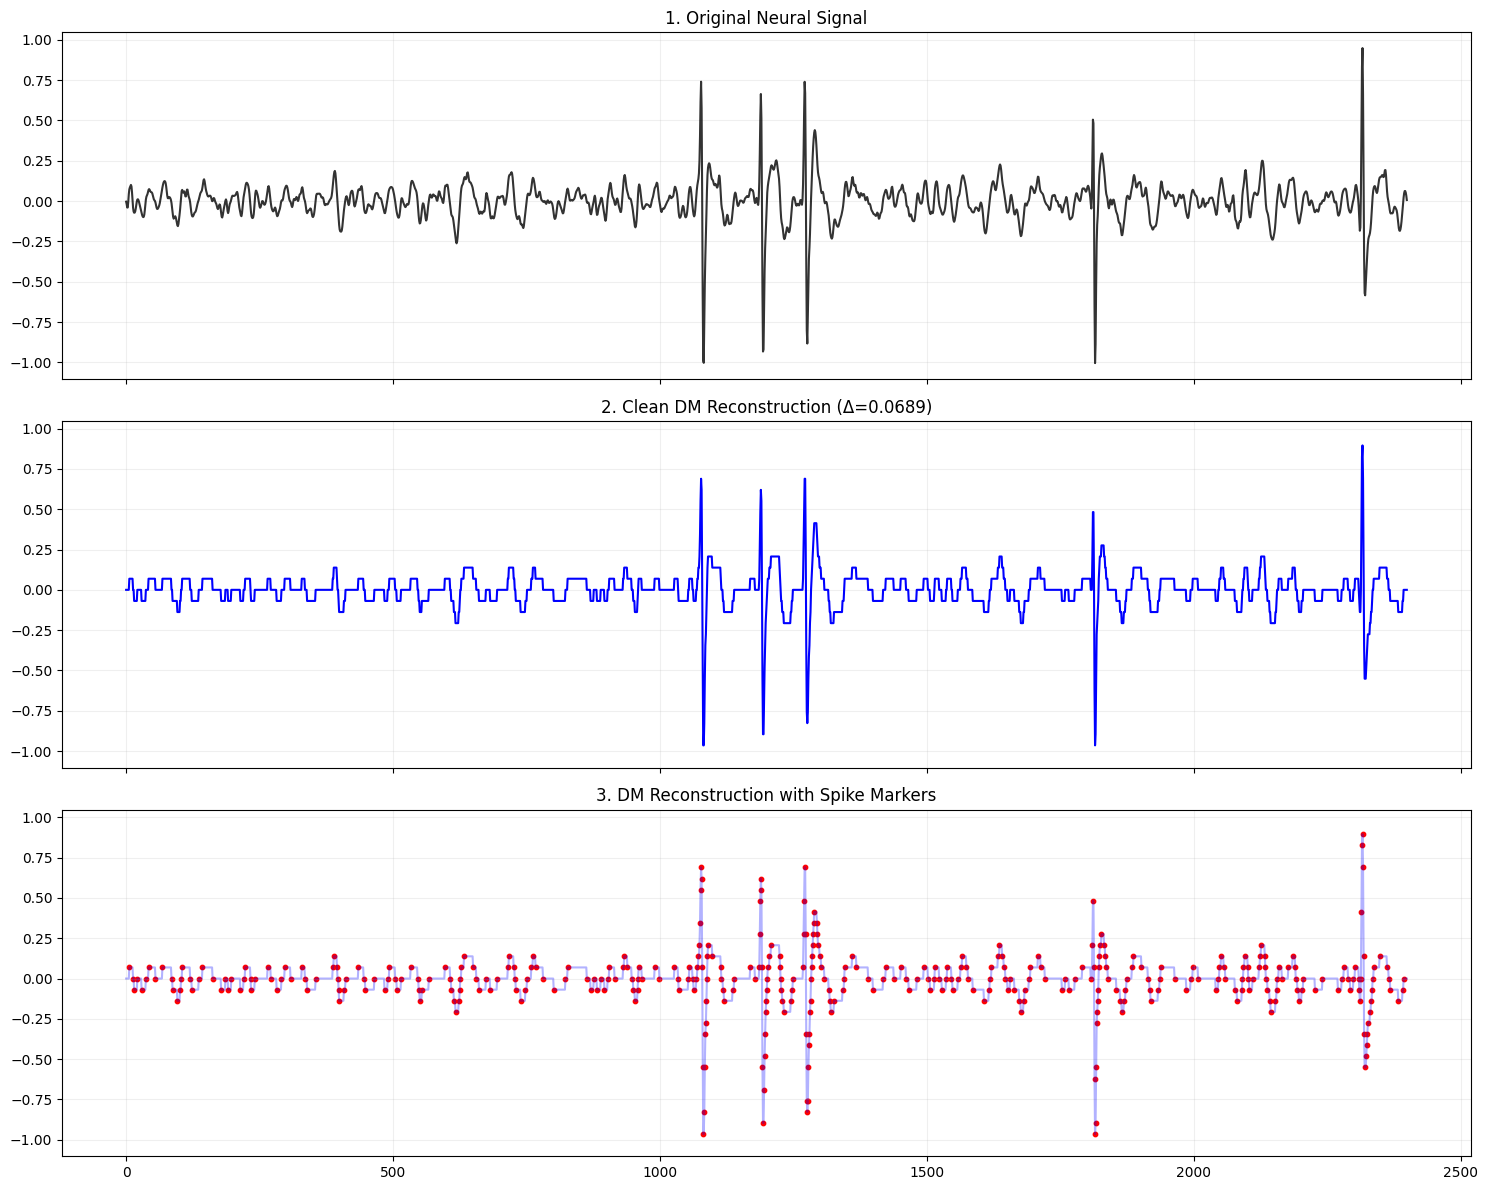

------------------------------
OPTIMIZATION SUMMARY
------------------------------
Optimal Threshold: ON=0.0689, OFF=-0.0689
Compression Rate:  6.12:1
Final Data Rate:   3921 pulses/sec
Spike RMSE:        0.0347


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy.io import loadmat
from kneed import KneeLocator
# ==========================================
# 1. Synthetic Data Generation
# ==========================================
try:
    MAT = loadmat('./C_Difficult1_noise01.mat')  # <-- your dataset
    rawData = np.array(MAT['data'])[0]
    sampling_interval = np.array(MAT['samplingInterval'][0][0]) * 1e-3
    sample_rate = int(1 / sampling_interval)
    data = rawData[:int(sample_rate)] # Use 1 second
except FileNotFoundError:
    print("Warning: .mat file not found. Generating synthetic data.")
    sample_rate = 24000
    t = np.linspace(0, 1, sample_rate)
    data = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)

# Band-pass filter
b, a = butter(4, [300 * 2 / sample_rate, 5000 * 2 / sample_rate], btype='band')
data = lfilter(b, a, data)


time_axis = np.arange(len(data))

# ==========================================
# 2. Core Logic Functions
# ==========================================
def delta_modulation_PCM(x, on_th, off_th):
    """Asynchronous Delta Modulation with pulse list return"""
    if on_th <= 0: raise ValueError("on_th must be positive.")
    if off_th >= 0: raise ValueError("off_th must be negative.")

    pulseTrain = np.zeros(len(x), dtype=int)
    y_rec = np.zeros(len(x), dtype=float)
    spikes = [] 
    last = 0.0

    for i in range(len(x)):
        diff = x[i] - last
        if diff > on_th:
            k = int(np.floor(diff / on_th))
            pulseTrain[i] = k
            last = last + k * on_th
            spikes.append((i, k))
        elif diff < off_th:
            k = int(np.floor(diff / off_th)) 
            pulseTrain[i] = -k                    
            last = last + k * off_th             
            spikes.append((i, -k))
        y_rec[i] = last
    return pulseTrain, y_rec, spikes

def spk_rmse(data, reconstructed_signal, spikeTimeGT):
    data_spk, reconstructed_spk = [], []
    valid_spikes = spikeTimeGT[spikeTimeGT < (len(data) - 48)]
    for i in valid_spikes:
        eval_idx = int(i)
        recon_section = reconstructed_signal[eval_idx : eval_idx + 48]
        data_section = data[eval_idx : eval_idx + 48]
        data_spk.extend(data_section)
        reconstructed_spk.extend(recon_section)
    if len(data_spk) == 0: return 0
    return np.sqrt(np.mean((np.array(data_spk) - np.array(reconstructed_spk))**2))

def find_knee(x, y):
    coords = np.vstack((x, y)).T
    first_pt = coords[0]; last_pt = coords[-1]
    line_vec = last_pt - first_pt
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = coords - first_pt
    scalar_prod = np.sum(vec_from_first * line_vec_norm, axis=1)
    vec_to_line = vec_from_first - np.outer(scalar_prod, line_vec_norm)
    dist_to_line = np.sqrt(np.sum(vec_to_line**2, axis=1))
    knee_idx = np.argmax(dist_to_line)
    return x.iloc[knee_idx], y.iloc[knee_idx], knee_idx

# ==========================================
# 3. Parameter Sweep (Optimization)
# ==========================================
deltas = np.logspace(np.log10(0.005), np.log10(0.5), 80)
results = []

for d in deltas:
    pt, y_rec, _ = delta_modulation_PCM(data, d, -d)
    rmse = spk_rmse(data, y_rec, spikeTimeGT)
    data_rate = np.sum(np.abs(pt) != 0) / duration
    comp_rate = sample_rate / data_rate if data_rate > 0 else np.nan
    results.append({"delta": d, "RMSE": rmse, "DataRate": data_rate, "CR": comp_rate})

df = pd.DataFrame(results).dropna().sort_values("delta")
opt_drate, opt_rmse, opt_idx = find_knee(df["DataRate"], df["RMSE"])
opt_delta = df.iloc[opt_idx]["delta"]

# Final Optimized Data for Visualization
pt_opt, y_opt, spikes_opt = delta_modulation_PCM(data, opt_delta, -opt_delta)

# ==========================================
# 4. Final Visualization (Metrics)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: RMSE vs Delta
axes[0, 0].plot(df["delta"], df["RMSE"], 'r-o', markersize=3)
axes[0, 0].set_xscale('log')
axes[0, 0].set_title("RMSE vs Delta (Threshold Selection)")
axes[0, 0].set_xlabel("Delta (Threshold Value)")
axes[0, 0].set_ylabel("Spike RMSE")
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Data Rate vs Delta
axes[0, 1].plot(df["delta"], df["DataRate"], 'b-s', markersize=3)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title("Data Rate vs Delta")
axes[0, 1].set_xlabel("Delta (Threshold Value)")
axes[0, 1].set_ylabel("Pulses Per Second")
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: RMSE vs Compression Rate
axes[1, 0].plot(df["CR"], df["RMSE"], 'g-^', markersize=3)
axes[1, 0].set_title("Distortion vs Compression Rate")
axes[1, 0].set_xlabel("Compression Rate (Original / Pulse Rate)")
axes[1, 0].set_ylabel("Spike RMSE")
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Rate-Distortion Curve with Knee
axes[1, 1].plot(df["DataRate"], df["RMSE"], 'm-', linewidth=2)
axes[1, 1].plot(opt_drate, opt_rmse, 'ko', markersize=8, label=f'Optimal Knee (Delta={opt_delta:.3f})')
axes[1, 1].set_title("Rate-Distortion Curve (Knee Detection)")
axes[1, 1].set_xlabel("Data Rate (pulses/sec)")
axes[1, 1].set_ylabel("RMSE")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 5. 3-Stage Breakdown Visualization
# ==========================================
lim_zoom = int(0.1 * sample_rate)
spikes_zoom = [s for s in spikes_opt if s[0] < lim_zoom]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, sharey=True)

# Plot 1: Original
ax1.plot(time_axis[:lim_zoom], data[:lim_zoom], color='black', alpha=0.8, label="Original")
ax1.set_title("1. Original Neural Signal")
ax1.grid(True, alpha=0.2)

# Plot 2: Reconstruction
ax2.plot(time_axis[:lim_zoom], y_opt[:lim_zoom], color='blue', label="Clean Reconstruction")
ax2.set_title(f"2. Clean DM Reconstruction (Δ={opt_delta:.4f})")
ax2.grid(True, alpha=0.2)

# Plot 3: Reconstruction with Spikes
ax3.plot(time_axis[:lim_zoom], y_opt[:lim_zoom], color='blue', alpha=0.3)
spike_indices = [s[0] for s in spikes_zoom]
spike_times = [time_axis[i] for i in spike_indices]
spike_values = [y_opt[i] for i in spike_indices]
ax3.scatter(spike_times, spike_values, c='red', s=10, label="Spikes")
ax3.set_title("3. DM Reconstruction with Spike Markers")
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Final Summary Output
print("-" * 30)
print(f"OPTIMIZATION SUMMARY")
print("-" * 30)
print(f"Optimal Threshold: ON={opt_delta:.4f}, OFF={-opt_delta:.4f}")
print(f"Compression Rate:  {df.iloc[opt_idx]['CR']:.2f}:1")
print(f"Final Data Rate:   {opt_drate:.0f} pulses/sec")
print(f"Spike RMSE:        {opt_rmse:.4f}")

Done: C_Easy1_noise005.mat
Done: C_Easy2_noise005.mat
Done: C_Difficult1_noise005.mat
Done: C_Difficult2_noise005.mat
Done: C_Easy1_noise01.mat
Done: C_Easy2_noise01.mat
Done: C_Difficult1_noise01.mat
Done: C_Difficult2_noise01.mat
Done: C_Easy1_noise015.mat
Done: C_Easy2_noise015.mat
Done: C_Difficult1_noise015.mat
Done: C_Difficult2_noise015.mat
Done: C_Easy1_noise02.mat
Done: C_Easy2_noise02.mat
Done: C_Difficult1_noise02.mat
Done: C_Difficult2_noise02.mat


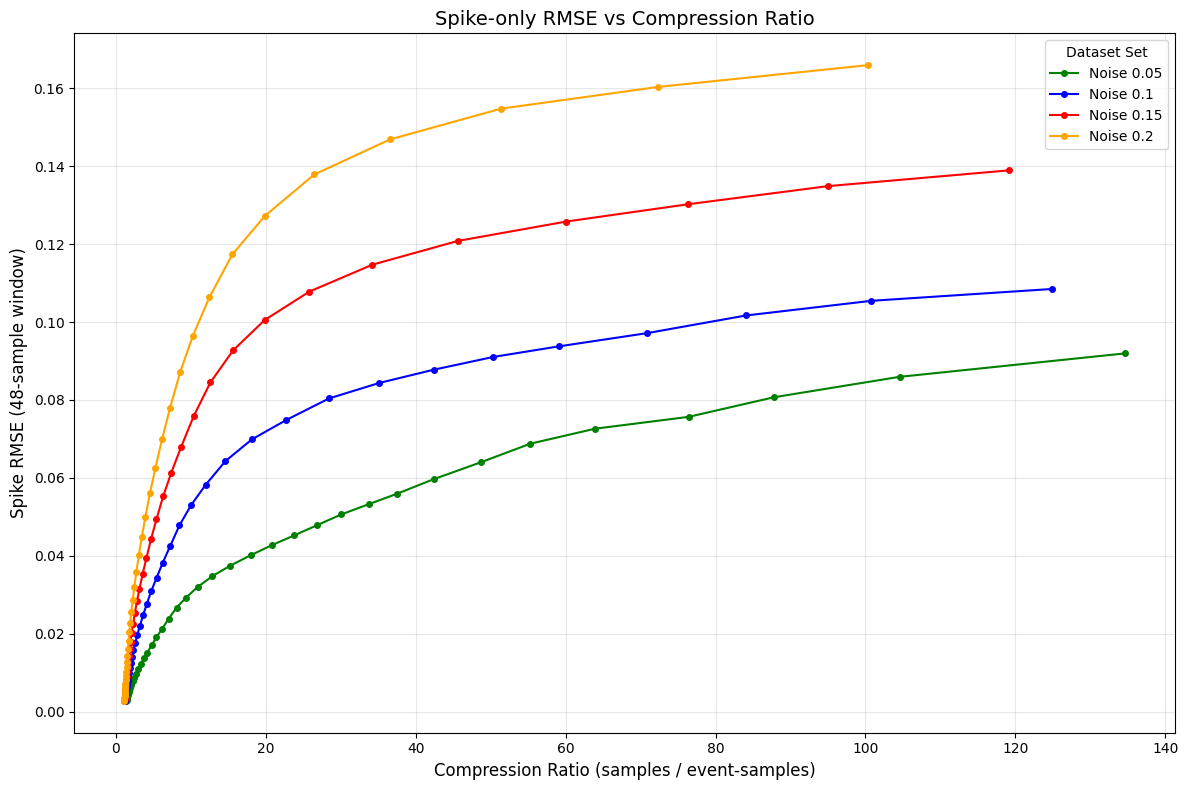

In [2]:
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# ==========================================
# 1. Core Logic Functions
# ==========================================

def delta_modulation_PCM(x, on_th, off_th):
    """Asynchronous Delta Modulation"""
    pulseTrain = np.zeros(len(x), dtype=int)
    y_rec = np.zeros(len(x), dtype=float)
    last = 0.0
    for i in range(len(x)):
        diff = x[i] - last
        if diff > on_th:
            k = int(np.floor(diff / on_th))
            pulseTrain[i] = k
            last += k * on_th
        elif diff < off_th:
            k = int(np.floor(diff / off_th)) 
            pulseTrain[i] = -k                    
            last += k * off_th             
        y_rec[i] = last
    return pulseTrain, y_rec

def spk_rmse(data, reconstructed_signal, spikeTimeGT):
    """Calculates RMSE only at spike locations (48-sample window)"""
    data_spk, reconstructed_spk = [], []
    # Ensure indices are within signal bounds
    valid_spikes = spikeTimeGT[(spikeTimeGT >= 0) & (spikeTimeGT < (len(data) - 48))]
    
    for i in valid_spikes:
        idx = int(i)
        data_section = data[idx : idx + 48]
        recon_section = reconstructed_signal[idx : idx + 48]
        data_spk.extend(data_section)
        reconstructed_spk.extend(recon_section)
        
    if len(data_spk) == 0: return 0
    return np.sqrt(np.mean((np.array(data_spk) - np.array(reconstructed_spk))**2))

# ==========================================
# 2. Configuration & Grouping
# ==========================================

noise_sets = {
    "Noise 0.05": ["C_Easy1_noise005.mat", "C_Easy2_noise005.mat", "C_Difficult1_noise005.mat", "C_Difficult2_noise005.mat"],
    "Noise 0.1":  ["C_Easy1_noise01.mat", "C_Easy2_noise01.mat", "C_Difficult1_noise01.mat", "C_Difficult2_noise01.mat"],
    "Noise 0.15": ["C_Easy1_noise015.mat", "C_Easy2_noise015.mat", "C_Difficult1_noise015.mat", "C_Difficult2_noise015.mat"],
    "Noise 0.2":  ["C_Easy1_noise02.mat", "C_Easy2_noise02.mat", "C_Difficult1_noise02.mat", "C_Difficult2_noise02.mat"]
}

sample_rate = 24000
deltas = np.logspace(np.log10(0.005), np.log10(0.5), 40) # Sweep thresholds


plt.figure(figsize=(12, 8))
colors = {"Noise 0.05": "green", "Noise 0.1": "blue", "Noise 0.15": "red", "Noise 0.2": "orange"}

# ==========================================
# 3. Processing and Averaging
# ==========================================

for label, files in noise_sets.items():
    all_file_rmse = []
    all_file_cr = []
    
    for filename in files:
        try:
            # 1. Load Data
            mat = sio.loadmat(filename)
            raw_sig = mat['data'].flatten()
            
            # 2. Extract Ground Truth Spike Indices
            # Quiroga files store spike times in ms. Convert to indices.
            st_cell = mat['spike_times']
            spike_indices = []
            for i in range(st_cell.shape[1]):
                times_ms = st_cell[0, i].flatten()
                indices = np.round((times_ms / 1000.0) * sample_rate).astype(int)
                spike_indices.extend(indices)
            spike_indices = np.sort(np.unique(spike_indices))
            
            # 3. Pre-Filter (Standard Bandpass)
            b, a = butter(4, [300*2/sample_rate, 5000*2/sample_rate], btype='band')
            data = lfilter(b, a, raw_sig)
            
            # 4. Sweep Delta Thresholds
            file_rmse, file_cr = [], []
            for d in deltas:
                pt, y_rec = delta_modulation_PCM(data, d, -d)
                
                # Metric 1: Spike-only RMSE
                rmse_val = spk_rmse(data, y_rec, spike_indices)
                
                # Metric 2: Compression Ratio (Original Samples / Total Pulses)
                pulses = np.sum(np.abs(pt) != 0)
                cr_val = len(data) / pulses if pulses > 0 else np.nan
                
                file_rmse.append(rmse_val)
                file_cr.append(cr_val)
            
            all_file_rmse.append(file_rmse)
            all_file_cr.append(file_cr)
            print(f"Done: {filename}")
            
        except Exception as e:
            print(f"Error loading {filename}: {e}")

    # Calculate and Plot Averages for the Noise Set
    if all_file_rmse:
        avg_rmse = np.nanmean(all_file_rmse, axis=0)
        avg_cr = np.nanmean(all_file_cr, axis=0)
        plt.plot(avg_cr, avg_rmse, '-o', markersize=4, label=label, color=colors[label])

# ==========================================
# 4. Formatting the Graph
# ==========================================

plt.title("Spike-only RMSE vs Compression Ratio", fontsize=14)
plt.xlabel("Compression Ratio (samples / event-samples)", fontsize=12)
plt.ylabel("Spike RMSE (48-sample window)", fontsize=12)
plt.grid(True, which='both', alpha=0.3)
plt.legend(title="Dataset Set")
plt.tight_layout()
plt.show()